# MACHINE LEARNING PROJECT

### Track T4 – Semi-Supervised Learning (SSL)
The objective of the project is to study and apply semi-supervised learning techniques to tabular data, analyzing how the limited availability of labels affects the performance of predictive models.

I'm interested in cybersecurity, so I chose the CSE-CIC-IDS2018 Intrusion CSVs (IDS 2018) dataset for the classification problem.

The dataset is based on logs from university servers, which recorded various DoS attacks during the publicly available period.
In total, there are eighty columns within this dataset, each of which corresponds to an entry in the IDS logging system that the Unversity of New Brunswick has in place.

Each entry in the dataset is originally labeled with multiple classes, such as Benign, FTP-BruteForce, and Other. To simplify the task and formulate it as a binary classification problem, I will consolidate all non-Benign labels into a single Malicious category. This way, the model will learn to distinguish between Benign and Malicious network traffic.

## Import libraries and models
I import the libraries and modules that we will need for the project.

In [1]:
#Imports
from sklearn.feature_selection import mutual_info_classif
from dask_ml.preprocessing import StandardScaler, Categorizer
from sklearn.linear_model import LogisticRegression
from sklearn.semi_supervised import SelfTrainingClassifier, LabelPropagation, LabelSpreading
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
import dask.dataframe as dd
import matplotlib.pyplot as plt
import dask.array as da
import numpy as np
import os

#Global vars
RANDOM_STATE = 7

## Load and manipulate the dataset
I load the dataset using only a single large CSV instead of all the files.This simplifies processing, avoids mismatched type issues, and reduces memory usage.  
At the same time, I convert all labels that are not "Benign" into a single "Malicious" category.  
I use Dask that is a library which performs lazy loading to avoid loading the entire dataset into memory.

Label
Benign       7372557
Malicious     576191
Name: count, dtype: int32
Malicious/Benign: 7.82%



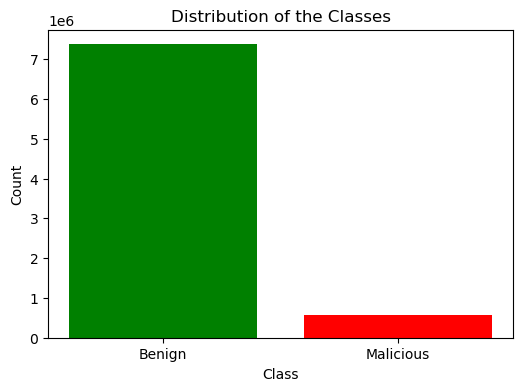

In [2]:
def showPlot(width, height, title, xDescription, yDescription, values, color):
    plt.figure(figsize = (width, height))
    plt.bar(values.index, values.values, color = color)
    plt.title(title)
    plt.xlabel(xDescription)
    plt.ylabel(yDescription)
    plt.show()

def showCounts(dataset, feature, reindex, rename, width, height, title, xDescription, yDescription, color, showPlotFlag):
    counts = dataset[feature].value_counts(dropna = False).compute()
    if(rename != None):
        counts = counts.rename(index = rename)
    if(reindex != None):
        counts = counts.reindex(reindex)
    counts = counts.fillna(0)  
    counts = counts.astype(int)
    print(f"{counts}\nMalicious/Benign: {counts.get('Malicious', 0) / counts.get('Benign', 0):.2%}\n")
    if(showPlotFlag):
        showPlot(width, height, title, xDescription, yDescription, counts, color)

def showPurity(dataset, showPlotFlag):
    dirty_entries_dt = dataset[dataset.isna().any(axis = 1)]
    dirty_entries = dirty_entries_dt.shape[0].compute()
    total_entries = dataset.shape[0].compute()
    clean_entries = total_entries - dirty_entries
    print(f"Entries that have at least 1 null feature value: {dirty_entries}\nTotal Entries: {total_entries}\nPercentage of dirty entries: {dirty_entries / total_entries:.2%}\n")
    if(dirty_entries > 0):
        print("Analyzing dirty entries:\n" , dirty_entries_dt["Label"].value_counts().compute(), "\n")
    if(showPlotFlag):
        counts = pd.Series([clean_entries, dirty_entries], index = ["Clean Entries", "Dirty Entries"])
        showPlot(6, 4, "Clean Entries vs Dirty Entries", "Type", "Count", counts, ["skyblue", "brown"])    

dataset = dd.read_csv("Dataset/02-20-2018.csv", assume_missing = True)
dataset["Label"] = dataset["Label"].map(lambda x: "Malicious" if x != "Benign" else "Benign")
showCounts(dataset, "Label", ["Benign", "Malicious"], None, 6, 4, "Distribution of the Classes", "Class", "Count", ["green", "red"], True)

### Cleaning dirty entries
Now I check the entire dataset for entries with any missing feature values.

Entries that have at least 1 null feature value: 36767
Total Entries: 7948748
Percentage of dirty entries: 0.46%

Analyzing dirty entries:
 Label
Benign    36767
Name: count, dtype: int64 



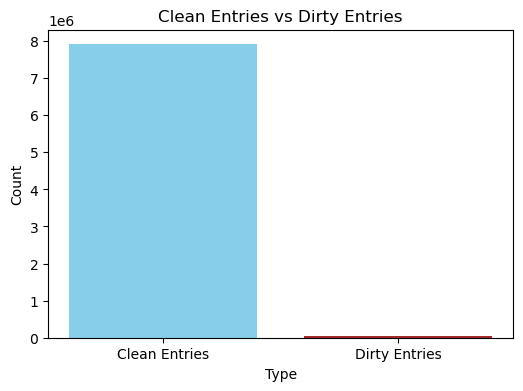

In [3]:
showPurity(dataset, True)

At this stage, we observe that entries with missing values represent less than 1% of the overall dataset. Removing features or attempting to impute missing values is not appropriate at this point, since most features are important for traffic analysis and will be further examined during the subsequent analysis phase. Moreover, filling missing values in network traffic data would be unreliable and could introduce noise, potentially distorting the underlying patterns. For these reasons, I will remove the incomplete entries from the dataset.

Additionally, as previously noted, the dataset is heavily imbalanced toward Benign traffic, as it contains a significantly larger number of such samples. Therefore, removing these already limited “dirty” entries, which are all classified as Benign, is further justified and does not negatively impact the representativeness of the dataset.

Entries that have at least 1 null feature value: 0
Total Entries: 7911981
Percentage of dirty entries: 0.00%



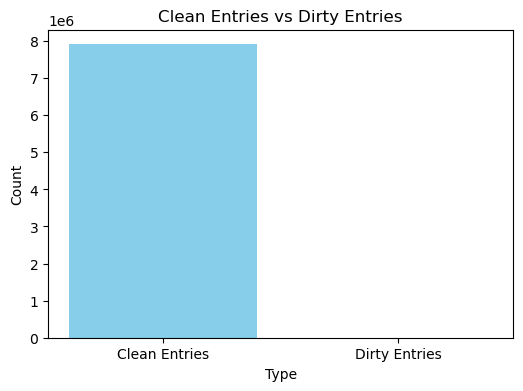

In [4]:
dataset = dataset.dropna()
showPurity(dataset, True)

### Analyzing infinite values
I analyze which features include infinite values across their entries.

In [5]:
numeric_features = dataset.select_dtypes(include=[np.number])
features_inf = list(numeric_features.columns[np.isinf(numeric_features).any(axis = 0)])
print(f"Features containing infinite values: {features_inf}")

Features containing infinite values: ['Flow Byts/s', 'Flow Pkts/s']


Now, I  check how many entries contain infinite values in those features.

Label
Benign       22686
Malicious        0
Name: count, dtype: int32
Malicious/Benign: 0.00%



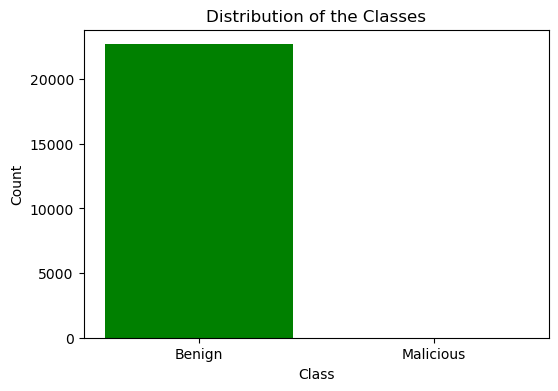

In [6]:
mask_inf = np.isinf(dataset[features_inf]).any(axis=1)
dataset_inf = dataset.loc[mask_inf]
showCounts(dataset_inf, "Label", ["Benign", "Malicious"], None, 6, 4, "Distribution of the Classes", "Class", "Count", ["green", "red"], True)

Since all detected samples containing infinite values belong to the benign class, and considering that the dataset is already strongly imbalanced, these entries can be safely removed without significantly affecting the representation of the minority (malicious) class.

Label
Benign       7313104
Malicious     576191
Name: count, dtype: int32
Malicious/Benign: 7.88%



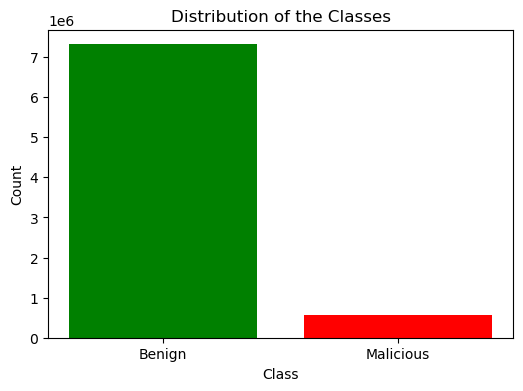

In [7]:
dataset = dataset.loc[~mask_inf]
showCounts(dataset, "Label", ["Benign", "Malicious"], None, 6, 4, "Distribution of the Classes", "Class", "Count", ["green", "red"], True)

## A Priori Feature Removal
This dataset contains network traffic analysis data between devices and university servers, so it is necessary to carefully examine all the features available in each entry and remove those that are not relevant for analyzing future network traffic and making predictions, thereby essentially avoiding model overfitting.  
### Showing features

In [8]:
print(dataset.columns, "\n\nNumber of features: ", dataset.shape[1])

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE 

Among all these features, I can surely remove the <span style="color:red"><b>Flow ID</b></span>, which is unique and therefore carries no weight in the learning process. The <span style="color:red"><b>destination IP</b></span> is not relevant because it only indicates which university server the packets are sent to and does not help distinguish malicious from benign traffic. Similarly, the <span style="color:red"><b>source IP</b></span> is not useful, as it could be spoofed and, like the destination IP, does not aid in discrimination; in fact, it can cause overfitting—if the model learns that a specific IP is benign, it will continue to trust it blindly, which is very dangerous. The <span style="color:red"><b>source port</b></span> is also not important, since it is often random and, being frequently unknown, analyzing it usually makes little sense. On the other hand, the destination port could be useful because malicious attacks often target well-known ports, such as those for DNS, email services, or Other services, so analyzing it can contribute to traffic analysis and model learning. The <span style="color:red"><b>timestamp</b></span> could be useful in a time series study, but in our case, we remove it because it does not provide any relevant information.

In [9]:
dataset = dataset.drop(["Flow ID", "Src IP", "Src Port", "Dst IP", "Timestamp"], axis = 1)
print(dataset.columns, "\n\nNumber of features: ", dataset.shape[1])

Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Siz

## Target Encoding
I analyze the types of the features.

In [10]:
print(dataset.dtypes)

Dst Port         float64
Protocol         float64
Flow Duration    float64
Tot Fwd Pkts     float64
Tot Bwd Pkts     float64
                  ...   
Idle Mean        float64
Idle Std         float64
Idle Max         float64
Idle Min         float64
Label             object
Length: 79, dtype: object


Before training the model, all input features are already in numerical format, and no categorical or textual variables are present in the dataset. The only categorical variable is the target label, which is encoded into a numerical representation prior to the train-test split to ensure compatibility with the learning algorithms.

In [11]:
cat_enc = Categorizer(columns = ["Label"])
dataset = cat_enc.fit_transform(dataset)
dataset["Label"] = dataset["Label"].cat.codes
dataset["Label"] = dataset["Label"].astype(int)
print(dataset.dtypes,"\n")
showCounts(dataset, "Label", ["Benign", "Malicious"], {0: "Benign", 1: "Malicious"}, None, None, None, None, None, None, False)

Dst Port         float64
Protocol         float64
Flow Duration    float64
Tot Fwd Pkts     float64
Tot Bwd Pkts     float64
                  ...   
Idle Mean        float64
Idle Std         float64
Idle Max         float64
Idle Min         float64
Label              int32
Length: 79, dtype: object 

Label
Benign       7313104
Malicious     576191
Name: count, dtype: int32
Malicious/Benign: 7.88%



## Create Training Set and Test set
Now we randomly split the dataset. As is well known, the training set is used to train the models, while the test set is used to evaluate the final performance on unseen data. In addition, a validation set is set aside and used during the training phase to monitor the model’s performance and support model selection and tuning. The random_state parameter, as the name suggests, is used to initialize the internal random number generator that determines how the data is split into training, validation, and test sets. According to the documentation, setting a random_state ensures that the split is reproducible. The validation set will therefore be used during training, while the test set is kept untouched until the final evaluation stage.

Since the dataset is managed using Dask, which processes data in chunks rather than loading it entirely into memory, I implemented a custom stratified split of the dataset. This choice was necessary because the library does not provide a built-in API comparable to that of scikit-learn for performing such operations.

In a simple yet effective way, the two classes were first separated into two different files. Then, for each file, each containing only one class, 70% of the data was assigned to the training set, 10% to the validation set and the remaining 20% to the test set. This approach ensures that each split maintains the same proportion of classes, improving the reliability and representativeness of the model evaluation.

I simulate a semi-supervised scenario in which 93% of the labels are unavailable in the training set; therefore, we create an additional copy of the training set where most of the labels have been removed (i.e., masked), while keeping only a small labeled subset. 

The supervised baseline is trained exclusively on the small labeled subset (7%), while the semi-supervised approach leverages both the labeled data and the remaining unlabeled portion (93%), enabling a fair comparison of their effectiveness under limited labeling conditions. It's applied the same previous approach so that preserves the class distribution across the splits

### Dataset Split
Now I will proceed with splitting the dataset.

Only_labeled:
Label
Benign       358446
Malicious     28493
Unlabeled         0
Name: count, dtype: int32
Malicious/Benign: 7.95%



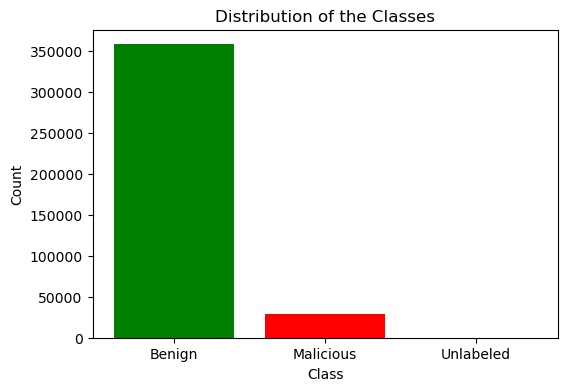

Semi_labeled:
Label
Benign        358446
Malicious      28493
Unlabeled    5136878
Name: count, dtype: int32
Malicious/Benign: 7.95%



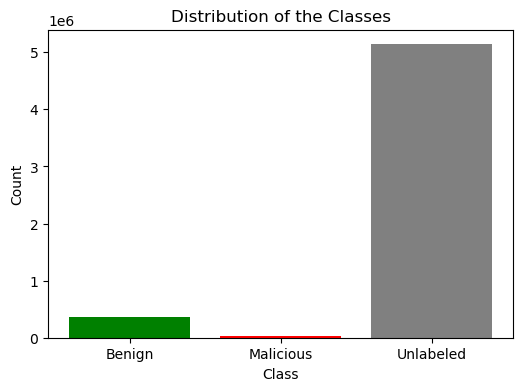

Validation:
Label
Benign       730229
Malicious     57659
Unlabeled         0
Name: count, dtype: int32
Malicious/Benign: 7.90%



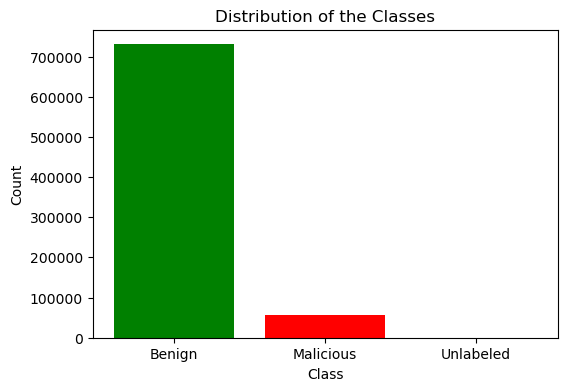

Test:
Label
Benign       1462143
Malicious     115447
Unlabeled          0
Name: count, dtype: int32
Malicious/Benign: 7.90%



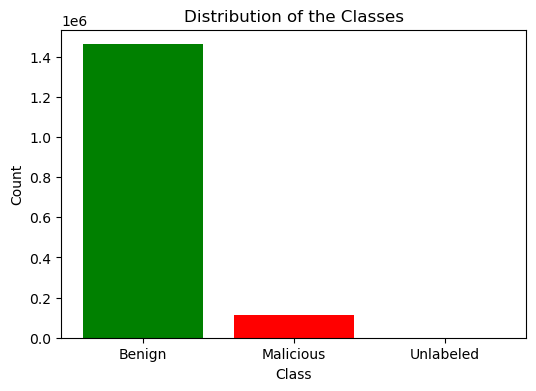

In [12]:
def saveData(dataset, path):
    dataset.to_csv(path, index = False, single_file = True)

def deleteData(path):
    if(os.path.isfile(path)):
        os.remove(path)

def divideDataset(dataset):
    benign = dataset[dataset["Label"] == 0]
    malicious = dataset[dataset["Label"] == 1]
    saveData(benign, "Dataset/benign_classes.csv")
    saveData(malicious, "Dataset/malicious_classes.csv")

def createTrainAndTestSetAndValidationSet(dataset_class1, dataset_class2):
    fractions = [0.7, 0.1, 0.2]
    fractions2 = [0.93, 0.07]
    train_set1, validation_set1, test_set1 = dataset_class1.random_split(fractions, random_state = RANDOM_STATE)
    train_set2, validation_set2, test_set2 = dataset_class2.random_split(fractions, random_state = RANDOM_STATE)
    train_set1_unlabeled, train_set1_labeled = train_set1.random_split(fractions2, random_state = RANDOM_STATE)
    train_set2_unlabeled, train_set2_labeled = train_set2.random_split(fractions2, random_state = RANDOM_STATE)
    train_set1_unlabeled["Label"] = -1
    train_set2_unlabeled["Label"] = -1
    train_set_only_labeled = dd.concat([train_set1_labeled, train_set2_labeled]) 
    train_set_only_labeled_shuffled = train_set_only_labeled.sample(frac = 1, random_state = RANDOM_STATE)  #trick to shuffle in Dask
    train_set_semi_labeled = dd.concat([train_set1_labeled, train_set2_labeled, train_set1_unlabeled, train_set2_unlabeled])
    train_set_semi_labeled_shuffled = train_set_semi_labeled.sample(frac = 1, random_state = RANDOM_STATE)  #trick to shuffle in Dask
    saveData(train_set_only_labeled_shuffled, "Dataset/train_set_only_labeled.csv")
    saveData(train_set_semi_labeled_shuffled, "Dataset/train_set_semi_labeled.csv")
    saveData(dd.concat([validation_set1, validation_set2]), "Dataset/validation_set.csv")
    saveData(dd.concat([test_set1, test_set2]), "Dataset/test_set.csv")
    
def stratified_train_test_split(dataset, overwrite):
    if not (os.path.isfile("Dataset/train_set_only_labeled.csv") and os.path.isfile("Dataset/train_set_semi_labeled.csv") 
            and os.path.isfile("Dataset/test_set.csv") and os.path.isfile("Dataset/validation_set.csv")) or overwrite:
        if(overwrite):
            paths = ["Dataset/benign_classes.csv", "Dataset/malicious_classes.csv", "Dataset/train_set_only_labeled.csv",
                     "Dataset/train_set_semi_labeled.csv", "Dataset/validation_set.csv", "Dataset/test_set.csv"]
            for path in paths:
                deleteData(path)
        divideDataset(dataset)
        benign = dd.read_csv("Dataset/benign_classes.csv")
        malicious = dd.read_csv("Dataset/malicious_classes.csv")
        createTrainAndTestSetAndValidationSet(benign, malicious)
    train_set_only_labeled = dd.read_csv("Dataset/train_set_only_labeled.csv", dtype = {"Label": "int32"})   
    train_set_semi_labeled = dd.read_csv("Dataset/train_set_semi_labeled.csv", dtype = {"Label": "int32"})   
    validation_set = dd.read_csv("Dataset/validation_set.csv", dtype = {"Label": "int32"}) 
    test_set = dd.read_csv("Dataset/test_set.csv", dtype = {"Label": "int32"}) 
    return train_set_only_labeled, train_set_semi_labeled, validation_set, test_set
    
train_set_only_labeled, train_set_semi_labeled, validation_set, test_set = stratified_train_test_split(dataset, False)
datasets = [("Only_labeled", train_set_only_labeled), ("Semi_labeled", train_set_semi_labeled), ("Validation", validation_set), ("Test", test_set)]
for name, dt in datasets:
    print(f"{name}:")
    showCounts(dt, "Label", ["Benign", "Malicious", "Unlabeled"], {0: "Benign", 1: "Malicious", -1: "Unlabeled"}, 6, 4, "Distribution of the Classes", "Class", "Count", ['green', 'red', 'grey'], True)

## Preparing data for the model
As I see, these datasets were split correctly. Now I prepare the data for machine learning algorithms.

### Balancing
As can be observed, both in the fully labeled training set and in the semi-labeled training set, there is a strong class imbalance, with a clear predominance of benign samples.

According to a statistical study conducted by Cloudflare, approximately 6.8% of Internet traffic is associated with malicious activities. In the dataset under analysis, malicious instances account for about 7.8% of the total samples, which is consistent with real-world conditions.

To address this imbalance, oversampling techniques could be applied by increasing the number of minority class examples (e.g., through duplication), but this may lead to overfitting. Alternatively, undersampling techniques can be used by reducing the number of majority class samples, at the cost of potentially losing some information.

In this work, however, no explicit resampling techniques are applied in order to preserve the original distribution of the data within the training set. Modifying the class distribution could alter the representativeness of the dataset with respect to real-world traffic conditions.

Instead, the imbalance is handled during the modeling phase by assigning a balanced class weight to the learning algorithm. This approach allows the model to give higher importance to the minority (malicious) class without modifying the underlying data distribution, thereby improving its ability to correctly identify underrepresented samples.

In [13]:
#Function to show how to balance the dataset
def balancer(dataset, name):
    dataset_benign = dataset[dataset["Label"] == 0]
    dataset_malicious = dataset[dataset["Label"] != 0]
    fractionBalancer = 1/3
    dataset_benign = dataset_benign.sample(frac = fractionBalancer, random_state = RANDOM_STATE)
    dataset = dd.concat([dataset_benign, dataset_malicious])
    dataset = dataset.sample(frac = 1, random_state = RANDOM_STATE) #shuffle
    print(name)
    showCounts(dataset, "Label", ["Benign", "Malicious"], {0: "Benign", 1: "Malicious"}, 6, 4, "Distribution of the Classes", "Class", "Count", ['green', 'red'], True)
    return dataset

#Balancer not applied    
#train_set_only_labeled = balancer(train_set_only_labeled, "Train_set_only_labeled")   
#train_set_semi_labeled = balancer(train_set_semi_labeled, "Train_set_semi_labeled")

### Separation of input features and target labels
In this step, the datasets are split into input features (x) and target variables (y) for the training, validation, and test sets. This separation is performed for both the fully labeled dataset and the semi-supervised dataset in order to properly prepare the data for model training and evaluation.

In [14]:
x_train_only_labeled = train_set_only_labeled.drop("Label", axis = 1)
y_train_only_labeled = train_set_only_labeled["Label"]

x_train_semi_labeled = train_set_semi_labeled.drop("Label", axis = 1)
y_train_semi_labeled = train_set_semi_labeled["Label"]

x_validation = validation_set.drop("Label", axis = 1)
y_validation = validation_set["Label"]

x_test = test_set.drop("Label", axis = 1)
y_test = test_set["Label"]

### Analyzing correlation
Correlation analysis was performed on the fully labeled subset, and the same feature relationships were assumed to hold for the semi-supervised dataset, which extends the original distribution with unlabeled samples.

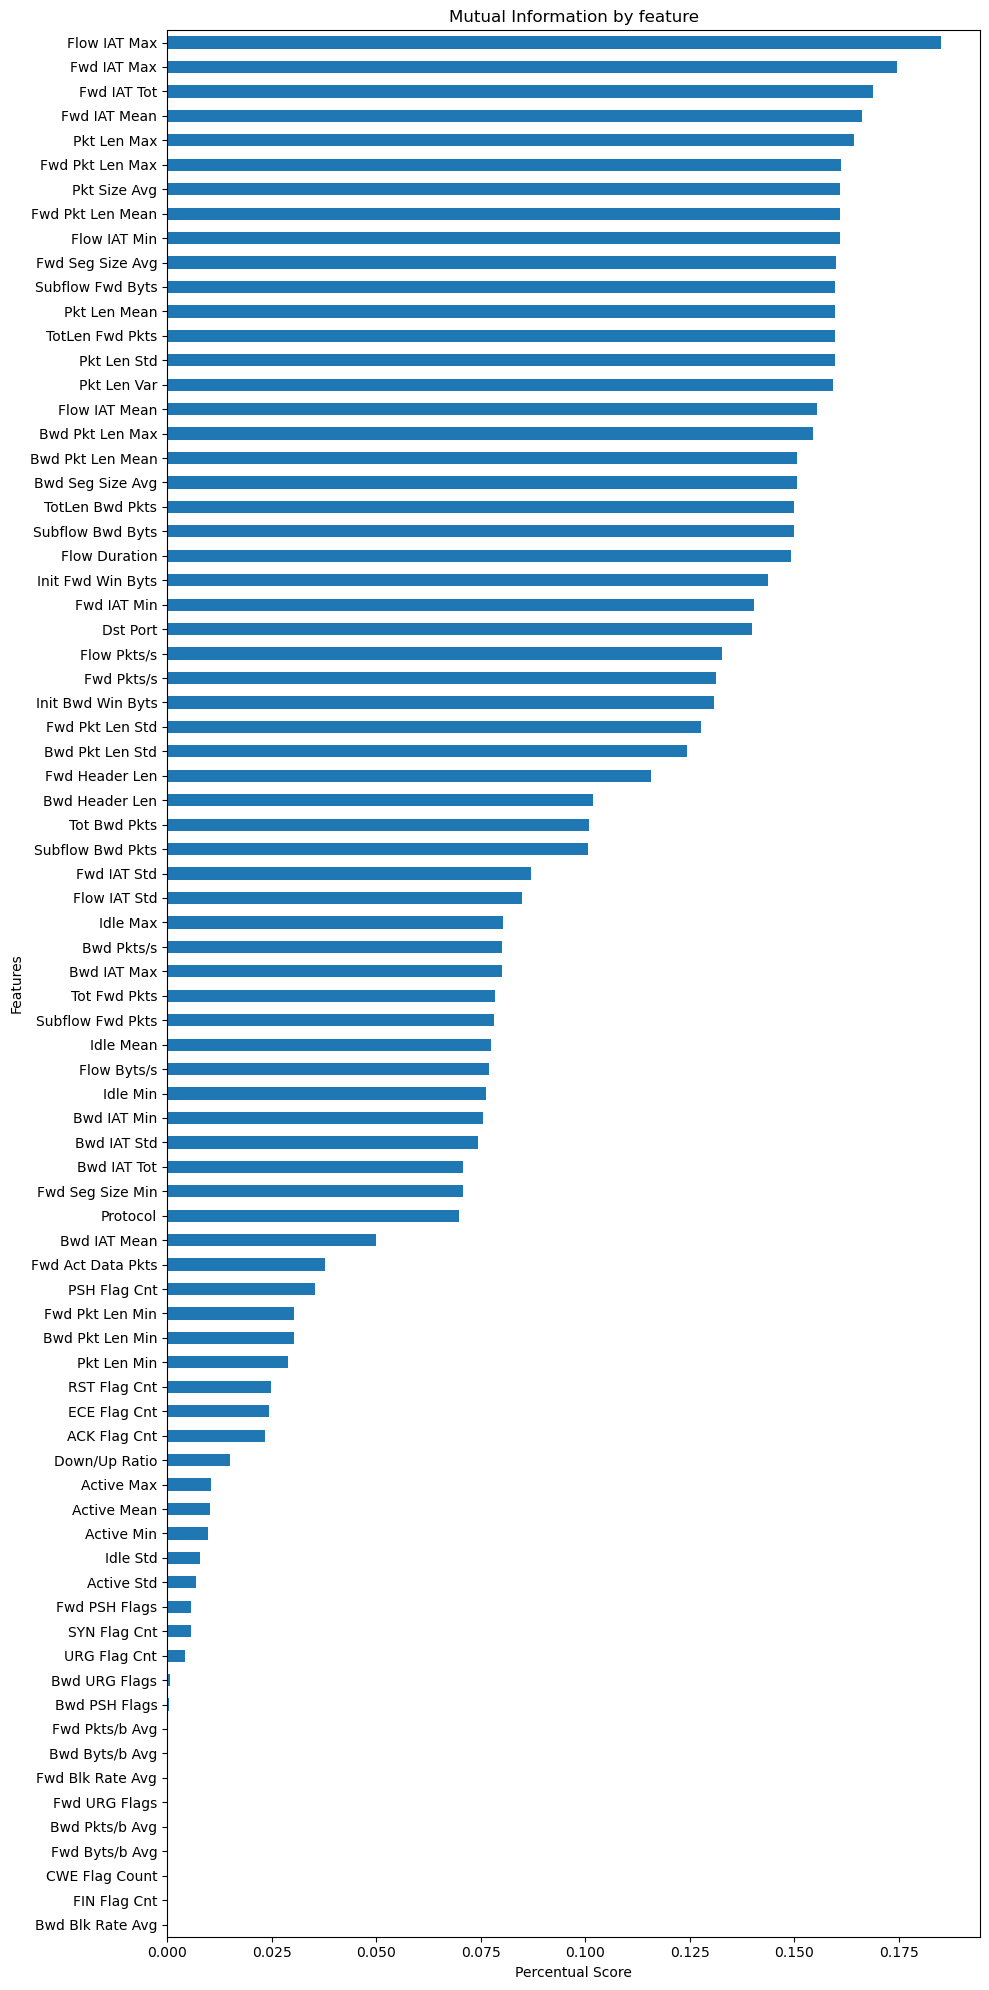

In [15]:
mutualInfoClassifier = mutual_info_classif(x_train_only_labeled, y_train_only_labeled)
mutualInfoClassifier_series = pd.Series(mutualInfoClassifier, index = x_train_only_labeled.columns).sort_values(ascending = False)

plt.figure(figsize = (10, 20))
mutualInfoClassifier_series.sort_values().plot(kind = "barh")
plt.title("Mutual Information by feature")
plt.xlabel("Percentual Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

Now I will remove all features that have less than 5% correlation with the target, and then I will rescale all features using StandardScaler.

In [16]:
x_train_only_labeled = x_train_only_labeled.drop(mutualInfoClassifier_series[mutualInfoClassifier_series < 0.05].index, axis = 1)
x_train_semi_labeled = x_train_semi_labeled.drop(mutualInfoClassifier_series[mutualInfoClassifier_series < 0.05].index, axis = 1)
x_validation = x_validation.drop(mutualInfoClassifier_series[mutualInfoClassifier_series < 0.05].index, axis = 1)
x_test = x_test.drop(mutualInfoClassifier_series[mutualInfoClassifier_series < 0.05].index, axis = 1)

print(x_train_only_labeled.columns, "\n\nNumber of features: ", x_train_only_labeled.shape[1])

Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max',
       'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Len', 'Bwd Header Len',
       'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'Pkt Size Avg', 'Fwd Seg Size Avg',
       'Bwd Seg Size Avg', 'Subflow Fwd Pkts', 'Subflow Fwd Byts',
       'Subflow Bwd Pkts', 'Subflow Bwd Byts', 'Init Fwd Win Byts',
       'Init Bwd Win Byts', 'Fwd Seg Size Min', 'Idle Mean', 'Idle Max',
       'Idle Min'],
      dtype='object') 

Number of features:  50


Now I will scale all features using StandardScaler for all datasets

In [17]:
scaler1 = StandardScaler()
x_train_only_labeled = scaler1.fit_transform(x_train_only_labeled)
x_validation_only_labeled = scaler1.transform(x_validation)
x_test_only_labeled = scaler1.transform(x_test)

scaler2 = StandardScaler()
x_train_semi_labeled = scaler2.fit_transform(x_train_semi_labeled)
x_validation_semi_labeled = scaler2.transform(x_validation)
x_test_semi_labeled = scaler2.transform(x_test)

## Semi-Supervised learning approaches
Within the context of semi-supervised learning, several approaches have been proposed to effectively exploit unlabeled data alongside a limited set of labeled examples. One widely used technique is self-training, a wrapper-based method in which a model is initially trained on labeled data and then iteratively assigns pseudo-labels to unlabeled instances based on high-confidence predictions. These newly labeled samples are subsequently incorporated into the training set, allowing the model to progressively refine its performance.

In addition, graph-based methods such as Label Propagation and Label Spreading provide an alternative perspective. In these approaches, data points are represented as nodes within a graph, where edges encode similarities between instances. Label Propagation directly spreads label information across the graph structure, whereas Label Spreading introduces a regularization mechanism that improves robustness, particularly in the presence of noisy data.

Overall, these methods aim to leverage the underlying structure of the data distribution in order to enhance classification performance, especially in scenarios where labeled data is scarce. 
## Choice of the model and the SSL approaches
As the classification model, I use logistic regression, a simple and effective approach for binary classification tasks. This choice is motivated by its solid performance on structured data and its ability to scale well to large datasets.

For completeness, the project also presents a comparison between a model trained using only 7% of the labeled data and models that additionally exploit the remaining 93% of unlabeled data. In particular, the latter are trained using three semi-supervised approaches: self-training, label propagation and label spreading.

From this point onward, the model training will be carried out using scikit-learn, as the processed datasets are of a reasonable size to be handled in memory (RAM). The work performed so far has been useful to simulate a more realistic scenario, where datasets are significantly larger and cannot be fully preprocessed or engineered in memory.

### Define The Model And Training
Now I instantiate the logistic regression model, train it on the dataset, and evaluate how it performs on the validation set.

              precision    recall  f1-score   support

           0   0.999999  0.991374  0.995668    730229
           1   0.901512  0.999983  0.948198     57659

    accuracy                       0.992004    787888
   macro avg   0.950755  0.995678  0.971933    787888
weighted avg   0.992791  0.992004  0.992194    787888



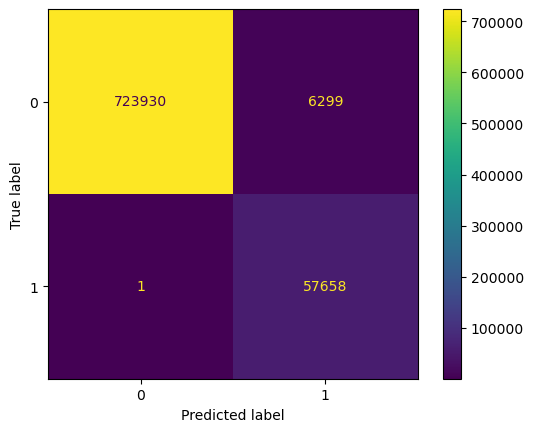

In [18]:
def showConfusionMatrix(y_val, y_pred):
    matrix = confusion_matrix(y_val, y_pred)   
    disp = ConfusionMatrixDisplay(confusion_matrix = matrix)
    disp.plot()
    plt.show()

model = LogisticRegression(class_weight = "balanced", max_iter = 1000)
model.fit(x_train_only_labeled, y_train_only_labeled)
y_val_pred = model.predict(x_validation_only_labeled)
report = classification_report(y_validation, y_val_pred, digits = 6)
print(report)
showConfusionMatrix(y_validation, y_val_pred)

As can be observed, although the labeled portion of the training set represents only about 7% of the original dataset, it still contains a very large number of examples; despite being highly imbalanced, assigning greater weight to the “1” (Malicious) class allows the logistic regression model to achieve very high overall performance. However, it also tends to classify some benign instances as malicious, leading to a slight deterioration in precision while maintaining an extremely high recall.

### Controlled Feature Reduction to Assess the Impact of Semi-Supervised Learning
As can be observed, the logistic regression model already achieves very strong performance; this is mainly due to the fact that the dataset is highly clean and extensively pre-engineered, making it particularly well-suited for supervised learning models. 

However, in realistic semi-supervised learning (SSL) scenarios, datasets are typically characterized by limited labeled data and reduced informational richness, which makes the learning task significantly more challenging. 

For this reason, and in order to simulate a more realistic and less informative setting, the feature space is deliberately reduced. Specifically, only a subset of features is retained, selected based on both domain recommendations provided by the original source and correlation analysis, namely: 
<span style="color: green;"><b>Dst Port (Destination Port)</b></span>, 
<span style="color: green;"><b>Protocol</b></span>, 
<span style="color: green;"><b>Flow Duration</b></span>, 
<span style="color: green;"><b>Tot Fwd Pkts (Total Forward Packets)</b></span>, 
and 
<span style="color: green;"><b>Tot Bwd Pkts (Total Backward Packets)</b></span>. 

This reduction is not intended to artificially degrade the model, but rather to simulate conditions of limited and partially informative feature availability, under which the benefits of SSL approaches can be more meaningfully evaluated. In this context, the increased uncertainty of the supervised model allows us to better highlight how semi-supervised techniques can leverage unlabeled data to improve predictive performance.

features = ["Dst Port", "Protocol", "Flow Duration", "Tot Fwd Pkts", "Tot Bwd Pkts"]
x_train_only_labeled = x_train_only_labeled[features]
x_validation_only_labeled = x_validation_only_labeled[features]
x_test_only_labeled = x_test_only_labeled[features]
x_train_semi_labeled = x_train_semi_labeled[features]
x_validation_semi_labeled = x_validation_semi_labeled[features]
x_test_semi_labeled = x_test_semi_labeled[features]

#### Retrying to train the model
I retry supervised learning

model.fit(x_train_only_labeled, y_train_only_labeled)
y_val_pred = model.predict(x_validation_only_labeled)
report = classification_report(y_validation, y_val_pred, digits = 6)
print(report)
showConfusionMatrix(y_validation, y_val_pred)

For class benign, the model has a precision of 0.999435, which means that almost every time it predicts benign, it is correct (only 363 false positives). However, the recall is 0.879306, so it does not capture all actual benign instances and produces some false negatives (88134 false negatives).

For class malicious, the model has a very high recall (0.993704), meaning it correctly identifies almost all true malicious instances (only 363 false negatives). However, the precision is quite low (0.393976), which indicates that many of the predictions for malicious are incorrect (88134 false positives).

Overall, the model tends to over-predict malicious traffic: it identifies nearly all malicious cases but at the cost of misclassifying many benign instances as malicious.

### Self Training  
Self-training is a semi-supervised learning approach where a model trained on labeled data is used to generate pseudo-labels for unlabeled data. Only the most confident predictions are added to the training set, and the model is retrained iteratively. This allows the model to leverage large amounts of unlabeled data, but it may propagate errors if incorrect predictions are included.

12 no_change 
               precision    recall  f1-score   support

           0   0.999999  0.988624  0.994279    730229
           1   0.874070  0.999983  0.932796     57659

    accuracy                       0.989455    787888
   macro avg   0.937034  0.994303  0.963538    787888
weighted avg   0.990783  0.989455  0.989779    787888



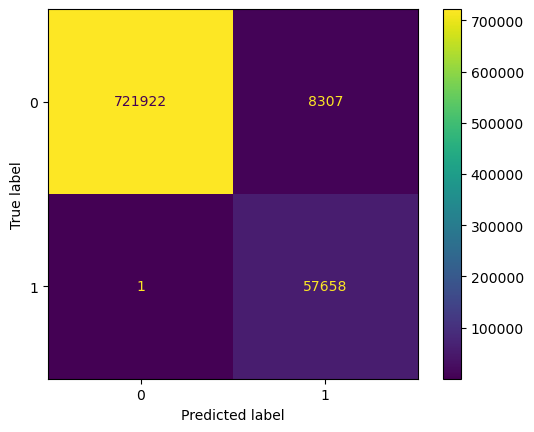

In [19]:
model2 = LogisticRegression(class_weight = "balanced", max_iter = 1000)
selfTrainingModel = SelfTrainingClassifier(model2, threshold = 0.9, max_iter = 20)
selfTrainingModel.fit(x_train_semi_labeled, y_train_semi_labeled)
y_val_pred = selfTrainingModel.predict(x_validation_semi_labeled)
report = classification_report(y_validation, y_val_pred, digits = 6)
print(selfTrainingModel.n_iter_, selfTrainingModel.termination_condition_, "\n", report)
showConfusionMatrix(y_validation, y_val_pred)

The classification report shows very strong overall performance, with an accuracy of 98.95% on a highly imbalanced dataset. In particular, class 0 (Benign) achieves near-perfect precision (0.999999) and very high recall (0.988624), while class 1 (Malicious) exhibits an almost perfect recall (0.999983) but a noticeably lower precision (0.874070), resulting in an F1-score of 0.932796.

Despite the availability of a very large dataset and the use of a simple logistic regression model with class weight balancing (giving more importance to the minority class “1” – Malicious), the application of the self-training wrapper provided by scikit-learn does not lead to an improvement in performance. On the contrary, although after 12 iterations the model successfully assigns labels to previously unlabeled instances, its overall behavior slightly deteriorates.

This effect becomes evident when analyzing the confusion matrix. The model tends to achieve extremely high recall for the Malicious class, meaning that false negatives are nearly zero. However, this comes at the cost of a non-negligible number of false positives. In other words, the model is overly inclined to classify instances as malicious even when they are not, which significantly reduces precision.

Even when adopting a high confidence threshold (e.g., 0.9) in the self-training process—intended to ensure that only highly confident predictions are used for pseudo-labeling the model still propagates errors. This leads to a gradual degradation in performance, as misclassified instances reinforce incorrect patterns during training rather than improving the model.

<span style="color:orange; font-weight:bold;">Warning:</span> Label Propagation and Label Spreading algorithms would require an enormous amount of RAM and, even if sufficient memory were available, a significant amount of computation time to be effectively used. Therefore, in order to demonstrate their effectiveness and more generally to simulate a realistic scenario in which the available data is much smaller than the current dataset, we can repeat our analysis by reducing each portion of the dataset to only 0.001% of the instances currently available.

### SSL Scenario With Limited Amount Of Data

#### Dataset Downsampling
First, I take the training set, validation set, test set and apply a reduction to 0.001% of their original size using the same function defined before to mantain the proportion.

Only_labeled:
Label
Benign       345
Malicious     23
Unlabeled      0
Name: count, dtype: int32
Malicious/Benign: 6.67%



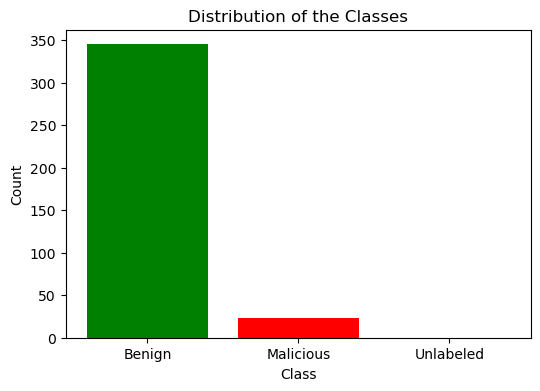

Semi_labeled:
Label
Benign        345
Malicious      23
Unlabeled    5088
Name: count, dtype: int32
Malicious/Benign: 6.67%



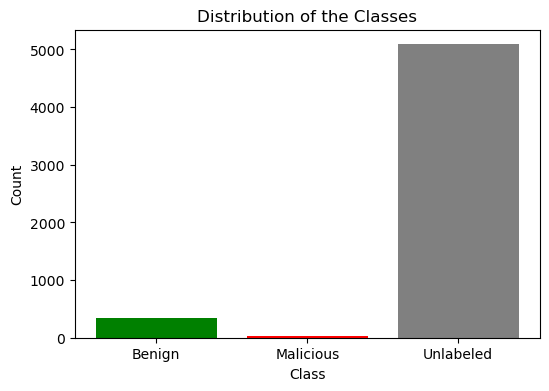

Validation:
Label
Benign       764
Malicious     76
Unlabeled      0
Name: count, dtype: int32
Malicious/Benign: 9.95%



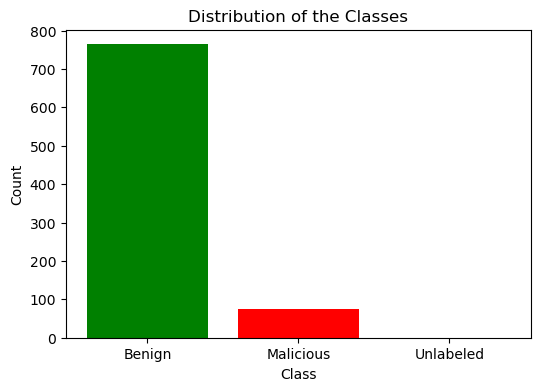

Test:
Label
Benign       1489
Malicious     105
Unlabeled       0
Name: count, dtype: int32
Malicious/Benign: 7.05%



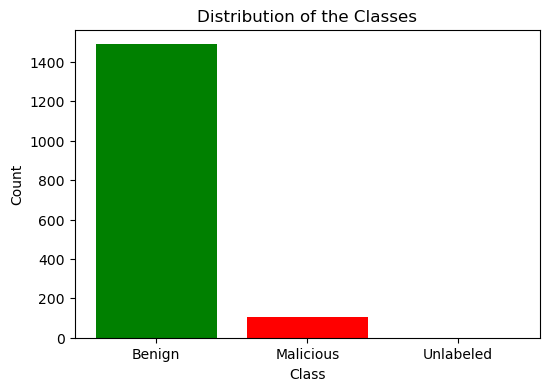

In [20]:
train_set_only_labeled, train_set_semi_labeled, validation_set, test_set = stratified_train_test_split(dataset.sample(frac = 0.001, random_state = RANDOM_STATE), True)
datasets = [("Only_labeled", train_set_only_labeled), ("Semi_labeled", train_set_semi_labeled), ("Validation", validation_set), ("Test", test_set)]
for name, dt in datasets:
    print(f"{name}:")
    showCounts(dt, "Label", ["Benign", "Malicious", "Unlabeled"], {0: "Benign", 1: "Malicious", -1: "Unlabeled"}, 6, 4, "Distribution of the Classes", "Class", "Count", ['green', 'red', 'grey'], True)

#### Reapplying Previous Data Preparation Steps  
Now I reapply the separation of features from the labels.

In [21]:
x_train_only_labeled = train_set_only_labeled.drop("Label", axis = 1)
y_train_only_labeled = train_set_only_labeled["Label"]

x_train_semi_labeled = train_set_semi_labeled.drop("Label", axis = 1)
y_train_semi_labeled = train_set_semi_labeled["Label"]

x_validation = validation_set.drop("Label", axis = 1)
y_validation = validation_set["Label"]

x_test = test_set.drop("Label", axis = 1)
y_test = test_set["Label"]

I do correlation analysis

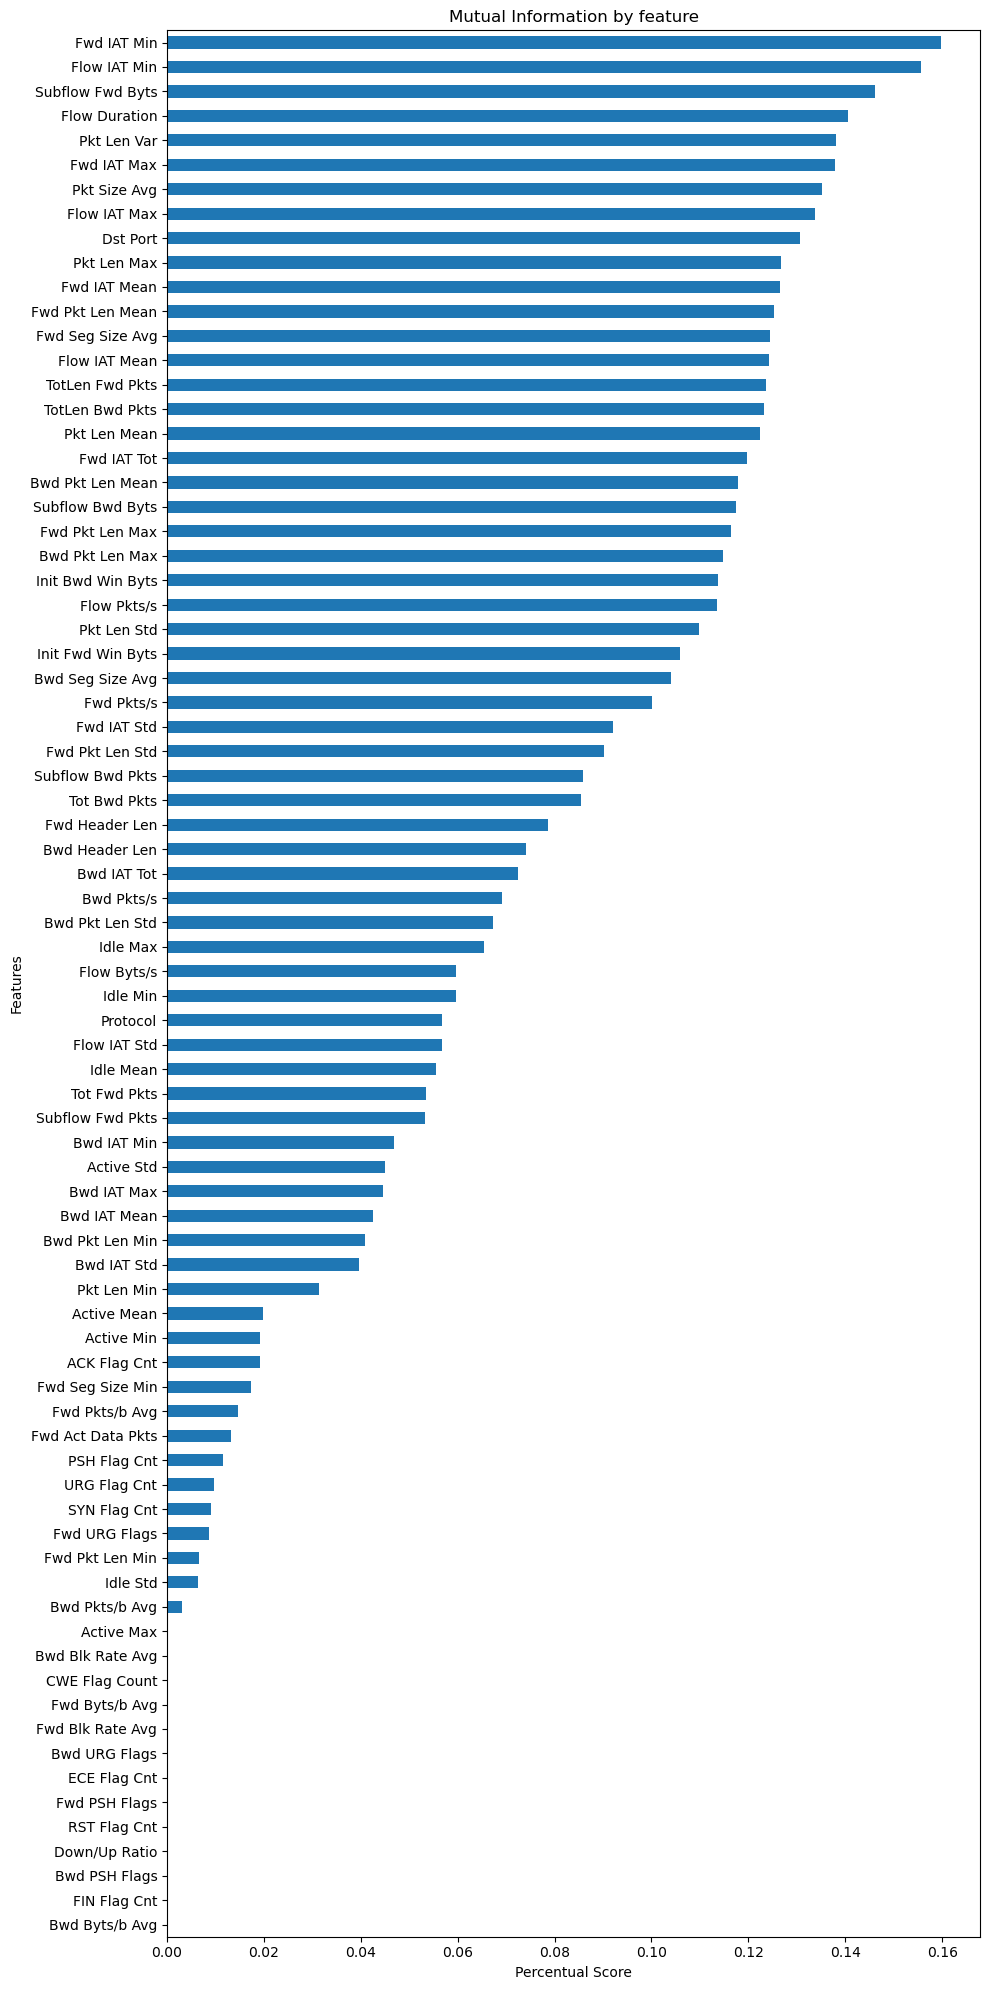

Index(['Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max',
       'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Tot', 'Fwd Header Len', 'Bwd Header Len',
       'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'Pkt Size Avg', 'Fwd Seg Size Avg',
       'Bwd Seg Size Avg', 'Subflow Fwd Pkts', 'Subflow Fwd Byts',
       'Subflow Bwd Pkts', 'Subflow Bwd Byts', 'Init Fwd Win Byts',
       'Init Bwd Win Byts', 'Idle Mean', 'Idle Max', 'Idle Min'],
      dtype='object') 

Number of features:  45


In [22]:
mutualInfoClassifier = mutual_info_classif(x_train_only_labeled, y_train_only_labeled)
mutualInfoClassifier_series = pd.Series(mutualInfoClassifier, index = x_train_only_labeled.columns).sort_values(ascending = False)

plt.figure(figsize = (10, 20))
mutualInfoClassifier_series.sort_values().plot(kind = "barh")
plt.title("Mutual Information by feature")
plt.xlabel("Percentual Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

x_train_only_labeled = x_train_only_labeled.drop(mutualInfoClassifier_series[mutualInfoClassifier_series < 0.05].index, axis = 1)
x_train_semi_labeled = x_train_semi_labeled.drop(mutualInfoClassifier_series[mutualInfoClassifier_series < 0.05].index, axis = 1)
x_validation = x_validation.drop(mutualInfoClassifier_series[mutualInfoClassifier_series < 0.05].index, axis = 1)
x_test = x_test.drop(mutualInfoClassifier_series[mutualInfoClassifier_series < 0.05].index, axis = 1)

print(x_train_only_labeled.columns, "\n\nNumber of features: ", x_train_only_labeled.shape[1])

I do feature scaling

In [23]:
x_train_only_labeled = scaler1.fit_transform(x_train_only_labeled)
x_validation_only_labeled = scaler1.transform(x_validation)
x_test_only_labeled = scaler1.transform(x_test)

x_train_semi_labeled = scaler2.fit_transform(x_train_semi_labeled)
x_validation_semi_labeled = scaler2.transform(x_validation)
x_test_semi_labeled = scaler2.transform(x_test)

#### Supervised Learning
Now I proceed to reapply the supervised training of the previously selected model using a significantly smaller available dataset.

              precision    recall  f1-score   support

           0   1.000000  0.937173  0.967568       764
           1   0.612903  1.000000  0.760000        76

    accuracy                       0.942857       840
   macro avg   0.806452  0.968586  0.863784       840
weighted avg   0.964977  0.942857  0.948788       840



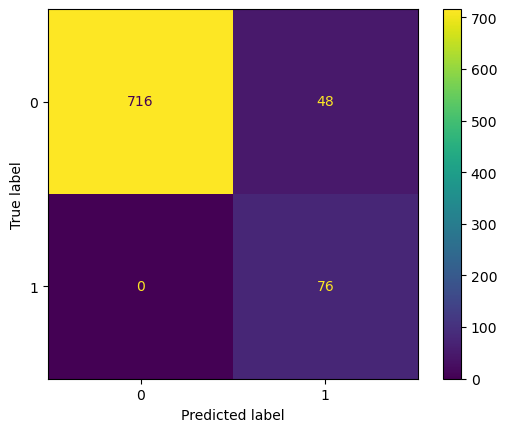

In [25]:
model.fit(x_train_only_labeled, y_train_only_labeled)
y_val_pred = model.predict(x_validation_only_labeled)
report = classification_report(y_validation, y_val_pred, digits = 6)
print(report)
showConfusionMatrix(y_validation, y_val_pred)

#### SSL Self Training
Now I proceed to reapply the semi-supervised self-training of the previously selected model using a significantly smaller available dataset.

6 no_change 
               precision    recall  f1-score   support

           0   1.000000  0.935864  0.966870       764
           1   0.608000  1.000000  0.756219        76

    accuracy                       0.941667       840
   macro avg   0.804000  0.967932  0.861544       840
weighted avg   0.964533  0.941667  0.947811       840



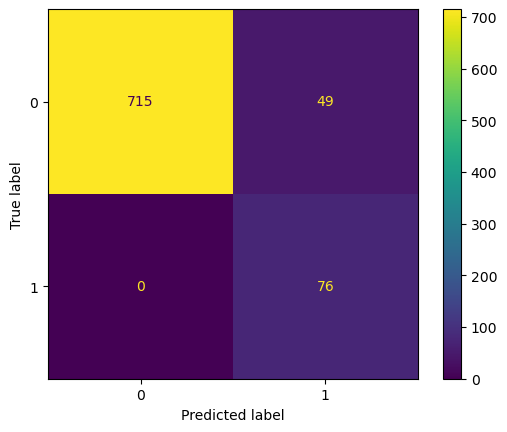

In [26]:
selfTrainingModel.fit(x_train_semi_labeled, y_train_semi_labeled)
y_val_pred = selfTrainingModel.predict(x_validation_semi_labeled)
report = classification_report(y_validation, y_val_pred, digits = 6)
print(selfTrainingModel.n_iter_, selfTrainingModel.termination_condition_, "\n", report)
showConfusionMatrix(y_validation, y_val_pred)

As previously shown, the issue with self-training remains unchanged.

#### Label Propagation  
Label Propagation is a semi-supervised learning algorithm used on graphs where only a small portion of the data is labeled and the rest is unlabeled. The main idea is that similar or connected nodes are likely to share the same label. The algorithm represents data as a graph where nodes are data points and edges represent similarity. Initially, labeled nodes keep their labels while unlabeled nodes have none. Then, in an iterative process, each node updates its label by looking at the labels of its neighbors, usually choosing the most frequent or strongly weighted label among them. This process repeats until the labels stop changing and the system converges. In the end, labels propagate through the graph from labeled nodes to unlabeled ones. Label Propagation is useful when labeled data is limited but relationships between data points are known, such as in social networks, text classification, or clustering tasks.

              precision    recall  f1-score   support

           0   1.000000  0.956806  0.977926       764
           1   0.697248  1.000000  0.821622        76

    accuracy                       0.960714       840
   macro avg   0.848624  0.978403  0.899774       840
weighted avg   0.972608  0.960714  0.963785       840



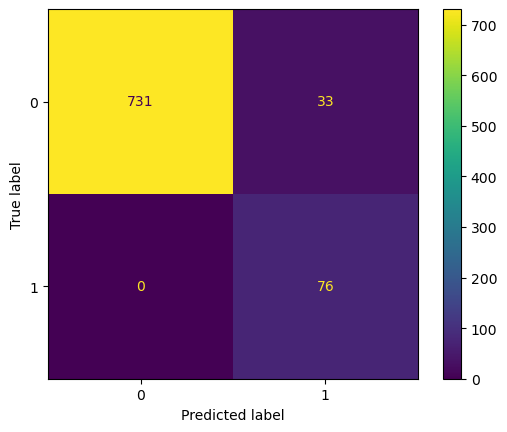

In [35]:
labelPropagation = LabelPropagation()
labelPropagation.fit(x_train_semi_labeled, y_train_semi_labeled)
y_propagated = labelPropagation.transduction_
model2.fit(x_train_semi_labeled, y_propagated)
y_val_pred = model2.predict(x_validation_semi_labeled)
report = classification_report(y_validation, y_val_pred, digits = 6)
print(report)
showConfusionMatrix(y_validation, y_val_pred)

As can be clearly seen, the model’s behavior with label propagation is certainly better and allows for more accurate predictions.

#### Label Spreading  
Label Spreading is a semi-supervised learning algorithm used on graphs where only a small portion of the data is labeled and the rest is unlabeled. The main idea is that similar or connected data points tend to share the same label, and labels are propagated through the graph based on these similarities.
Unlike Label Propagation, Label Spreading introduces a smoothing effect, meaning that even initially labeled points can slightly adjust their labels during the process. This makes the algorithm more robust to noise and reduces the risk of spreading incorrect labels. The method balances two objectives: staying close to the initial labels and ensuring smoothness across the graph structure.
In practice, Label Spreading iteratively updates labels based on neighboring nodes until convergence. It is particularly useful when labeled data is limited and potentially noisy, such as in social networks, text classification, or clustering tasks.

              precision    recall  f1-score   support

           0   1.000000  0.950262  0.974497       764
           1   0.666667  1.000000  0.800000        76

    accuracy                       0.954762       840
   macro avg   0.833333  0.975131  0.887248       840
weighted avg   0.969841  0.954762  0.958709       840



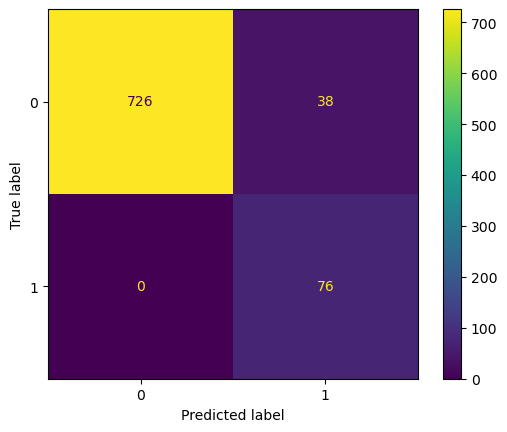

In [36]:
labelSpreading = LabelSpreading(kernel = 'rbf', gamma = 20)
labelSpreading.fit(x_train_semi_labeled, y_train_semi_labeled)
y_propagated = labelSpreading.transduction_
model2.fit(x_train_semi_labeled, y_propagated)
y_val_pred = model2.predict(x_validation_semi_labeled)
report = classification_report(y_validation, y_val_pred, digits = 6)
print(report)
showConfusionMatrix(y_validation, y_val_pred)

For label spreading, the behavior is consistently better than the standard model and also better than self-training in this scenario, but slightly inferior to label propagation. The latter methods, being very similar, therefore exhibit comparable characteristics.

#### Further Considerations  
Based on what has been observed in scenarios with strong class imbalance and limited data, using a relatively simple model such as logistic regression for binary classification, self-training does not appear to be a particularly suitable approach. Being a fairly simple algorithm, it tends to further propagate errors.

In contrast, the other two graph-based methods tend to classify instances based on proximity (i.e., the edges connecting nodes in the graph). Therefore, in this setting, they generally perform better than the first approach.

Now, I will proceed with tuning these two methods to evaluate whether the model can perform even better before the final testing phase.

In [37]:
from sklearn.metrics import f1_score

gammas = [0.01, 0.1, 1, 10]
kernels = ["rbf", "knn"]
best_score = -1
best_params = None

for gamma in gammas:
    for kernel in kernels:
        lpModel = LabelPropagation(kernel = kernel, gamma = gamma)
        lpModel.fit(x_train_semi_labeled, y_train_semi_labeled)
        y_pseudo = lpModel.transduction_
        model2.fit(x_train_semi_labeled, y_pseudo)
        y_pred = model2.predict(x_validation_semi_labeled)
        score = f1_score(y_validation, y_pred, average = "macro")
        if score > best_score:
            best_score = score
            best_params = (kernel, gamma)

print(best_params, best_score)

('rbf', 1) 0.9422495965964468


              precision    recall  f1-score   support

           0   0.996016  0.981675  0.988794       764
           1   0.839080  0.960526  0.895706        76

    accuracy                       0.979762       840
   macro avg   0.917548  0.971101  0.942250       840
weighted avg   0.981817  0.979762  0.980371       840



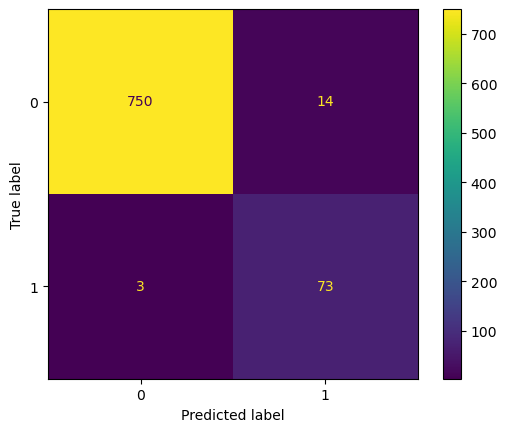

In [38]:
labelPropagation = LabelPropagation(kernel = best_params[0], gamma = best_params[1])
labelPropagation.fit(x_train_semi_labeled, y_train_semi_labeled)
y_propagated = labelPropagation.transduction_
model2.fit(x_train_semi_labeled, y_propagated)
y_val_pred = model2.predict(x_validation_semi_labeled)
report = classification_report(y_validation, y_val_pred, digits = 6)
print(report)
showConfusionMatrix(y_validation, y_val_pred)

In [39]:
alphas = [0.2, 0.5, 0.8]

best_score = -1
best_params = None

for kernel in kernels:
    for gamma in gammas:
        for alpha in alphas:
            lsModel = LabelSpreading(kernel = kernel, gamma = gamma, alpha = alpha)
            lsModel.fit(x_train_semi_labeled, y_train_semi_labeled)
            y_pseudo = lsModel.transduction_
            model2.fit(x_train_semi_labeled, y_pseudo)
            y_pred = model2.predict(x_validation_semi_labeled)
            score = f1_score(y_validation, y_pred, average = "macro")
            if score > best_score:
                best_score = score
                best_params = (kernel, gamma, alpha)

print("Best:", best_params, "Score:", best_score)

C:\Users\valba\.conda\envs\PROGETTO_ML_TRACCIA4\lib\site-packages\sklearn\semi_supervised\_label_propagation.py:322: ConvergenceWarning: max_iter=30 was reached without convergence.
  warnings.warn(
C:\Users\valba\.conda\envs\PROGETTO_ML_TRACCIA4\lib\site-packages\sklearn\semi_supervised\_label_propagation.py:322: ConvergenceWarning: max_iter=30 was reached without convergence.
  warnings.warn(
C:\Users\valba\.conda\envs\PROGETTO_ML_TRACCIA4\lib\site-packages\sklearn\semi_supervised\_label_propagation.py:322: ConvergenceWarning: max_iter=30 was reached without convergence.
  warnings.warn(
C:\Users\valba\.conda\envs\PROGETTO_ML_TRACCIA4\lib\site-packages\sklearn\semi_supervised\_label_propagation.py:322: ConvergenceWarning: max_iter=30 was reached without convergence.
  warnings.warn(
C:\Users\valba\.conda\envs\PROGETTO_ML_TRACCIA4\lib\site-packages\sklearn\semi_supervised\_label_propagation.py:322: ConvergenceWarning: max_iter=30 was reached without convergence.
  warnings.warn(


Best: ('rbf', 0.1, 0.2) Score: 0.9391852757577708


C:\Users\valba\.conda\envs\PROGETTO_ML_TRACCIA4\lib\site-packages\sklearn\semi_supervised\_label_propagation.py:322: ConvergenceWarning: max_iter=30 was reached without convergence.
  warnings.warn(


              precision    recall  f1-score   support

           0   0.996011  0.980366  0.988127       764
           1   0.829545  0.960526  0.890244        76

    accuracy                       0.978571       840
   macro avg   0.912778  0.970446  0.939185       840
weighted avg   0.980950  0.978571  0.979271       840



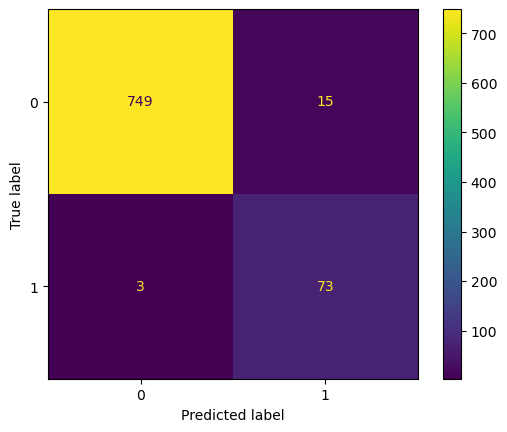

In [40]:
labelSpreading = LabelSpreading(kernel = best_params[0], gamma = best_params[1], alpha = best_params[2])
labelSpreading.fit(x_train_semi_labeled, y_train_semi_labeled)
y_propagated = labelSpreading.transduction_
model2.fit(x_train_semi_labeled, y_propagated)
y_val_pred = model2.predict(x_validation_semi_labeled)
report = classification_report(y_validation, y_val_pred, digits = 6)
print(report)
showConfusionMatrix(y_validation, y_val_pred)